## **Figure-S1**

These plots were assembled together to create the schematic.

In [1]:
# Colors - consistent with final version
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

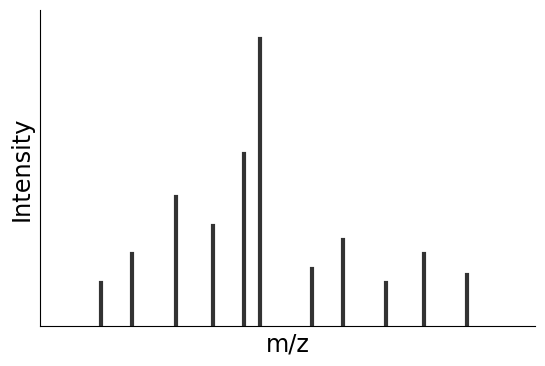

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# m/z axis (mass-to-charge ratio)
mz = np.linspace(200, 600, 1000)

# Gaussian function for peaks
def gaussian(x, mu, sigma, height):
    return height * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Define centroided peaks (discrete m/z values with heights)
peaks = [
    (250, 0.15),
    (275, 0.25),
    (310, 0.45),
    (340, 0.35),
    (365, 0.60),
    (378, 1.0),
    (420, 0.20),
    (445, 0.30),
    (480, 0.15),
    (510, 0.25),
    (545, 0.18),
]

plt.figure(figsize=(6, 4))
# Plot as stick spectrum (vertical lines)
ax = plt.gca()

# Assign colors cyclically to peaks for visualization
for i, (mz_val, intensity) in enumerate(peaks):
    color = colors[i % len(colors)]
    plt.plot([mz_val, mz_val], [0, intensity], color='black', lw=3, alpha=0.8, zorder=2)

# --- Add highlighting box around main peak group ---
box_left = 375
box_right = 385
box_bottom = 0
box_top = 1.05

# Axis labels
plt.xlabel("m/z", fontsize='xx-large')
plt.ylabel("Intensity", fontsize='xx-large')

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1.1)
ax.set_xlim(200, 600)

plt.tight_layout()

# Hide ticks
ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

plt.show()

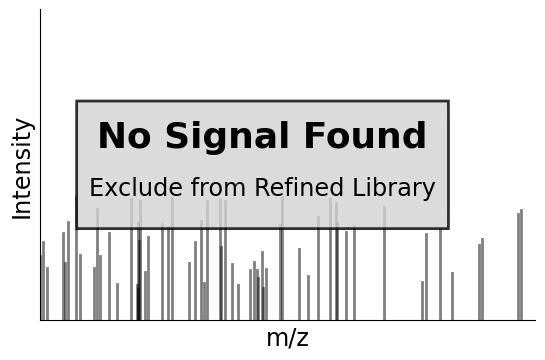

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.font_manager import FontProperties

# m/z axis
mz_values = np.linspace(200, 600, 100)

# Colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(6, 4))
ax = plt.gca()

# --- Random noise peaks (stick spectrum) ---
np.random.seed(42)
num_peaks = 60

for _ in range(num_peaks):
    mz_val = np.random.uniform(200, 600)
    intensity = np.random.uniform(0.1, 0.4)
    color = np.random.choice(colors)
    plt.plot([mz_val, mz_val], [0, intensity], color='black', lw=2, alpha=0.5, zorder=2)

# --- Text box: No Signal Found ---
x_pos = 380
y_pos = 0.5

box_style = "round,pad=0.08"
box_facecolor = "lightgray"
box_edgecolor = "black"
box_linewidth = 2
box_width = 300
box_height = 0.25

box_x = x_pos - (box_width / 2)
box_y = y_pos - (box_height / 2)

ax.add_patch(
    FancyBboxPatch(
        (box_x, box_y),
        box_width,
        box_height,
        boxstyle=box_style,
        fc=box_facecolor,
        ec=box_edgecolor,
        lw=box_linewidth,
        alpha=0.8,
        zorder=100
    )
)

# First line: bold and larger
xx_large = FontProperties(size='xx-large')
xxx_large = xx_large.copy()
xxx_large.set_size(xxx_large.get_size_in_points() * 1.5)
ax.text(
    x_pos,
    y_pos + 0.035,
    "No Signal Found",
    color="black",
    ha="center",
    va="bottom",
    fontproperties=xxx_large,
    fontweight='bold',
    zorder=200
)

# Second line: smaller
ax.text(
    x_pos,
    y_pos - 0.035,
    "Exclude from Refined Library",
    color="black",
    ha="center",
    va="top",
    fontsize='xx-large',
    zorder=200
)

# Axis labels
plt.xlabel("m/z", fontsize='xx-large')
plt.ylabel("Intensity", fontsize='xx-large')

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1)
ax.set_xlim(200, 600)

plt.tight_layout()

# Hide ticks
ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

plt.show()

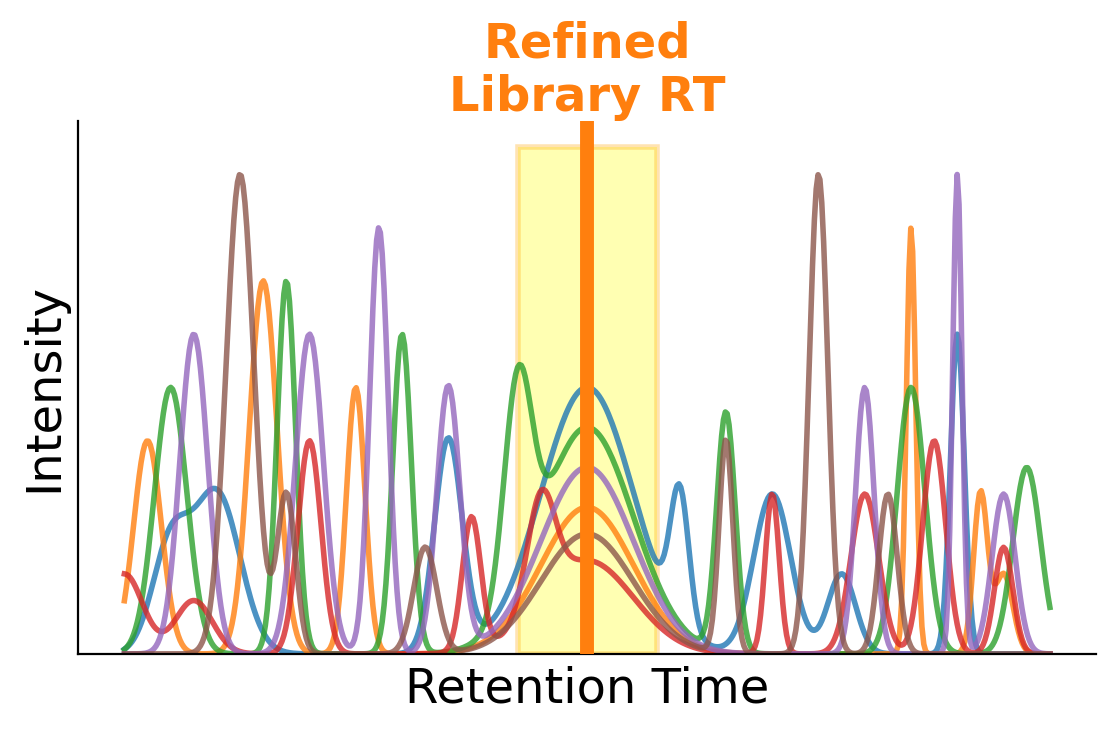

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Retention time axis
rt = np.linspace(40, 60, 500)  # RT range around 50

# Gaussian function
def gaussian(x, mu, sigma, height):
    return height * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Main peak group
mu = 50
sigma = 1
heights = np.array([1.0, 0.55, 0.85, 0.35, 0.7, 0.45]) * 0.5

# Colors - darker colors for better contrast with yellow highlight
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(6, 4), dpi=200)

# --- Main transitions ---
intensities = []
for h, c in zip(heights, colors):
    intensities.append(gaussian(rt, mu, sigma, h))

# --- Manually defined interference peaks ---
# Transition 0
intensities[0] += gaussian(rt, 42, 0.5, 0.3)
intensities[0] += gaussian(rt, 55.5, 0.3, 0.15)

# Transition 1
intensities[1] += gaussian(rt, 43, 0.3, 0.7)
intensities[1] += gaussian(rt, 57, 0.1, 0.8)
intensities[1] += gaussian(rt, 59, 0.2, 0.15)

# Transition 2
intensities[2] += gaussian(rt, 46, 0.2, 0.6)
intensities[2] += gaussian(rt, 57, 0.3, 0.5)

# Transition 3
intensities[3] += gaussian(rt, 41.5, 0.4, 0.1)
intensities[3] += gaussian(rt, 56, 0.3, 0.3)
intensities[3] += gaussian(rt, 59, 0.2, 0.2)

# Transition 4
intensities[4] += gaussian(rt, 44, 0.3, 0.6)
intensities[4] += gaussian(rt, 58, 0.1, 0.9)

# Transition 5
intensities[5] += gaussian(rt, 42.5, 0.3, 0.9)
intensities[5] += gaussian(rt, 55, 0.2, 0.9)

# --- Add many more interference peaks ---
# Transition 0 - additional interferences
intensities[0] += gaussian(rt, 41, 0.4, 0.2)
intensities[0] += gaussian(rt, 47, 0.3, 0.4)
intensities[0] += gaussian(rt, 52, 0.2, 0.25)
intensities[0] += gaussian(rt, 54, 0.4, 0.3)
intensities[0] += gaussian(rt, 58, 0.15, 0.6)

# Transition 1 - additional interferences
intensities[1] += gaussian(rt, 40.5, 0.3, 0.4)
intensities[1] += gaussian(rt, 45, 0.2, 0.5)
intensities[1] += gaussian(rt, 58.5, 0.15, 0.3)

# Transition 2 - additional interferences
intensities[2] += gaussian(rt, 41, 0.35, 0.5)
intensities[2] += gaussian(rt, 43.5, 0.2, 0.7)
intensities[2] += gaussian(rt, 48.5, 0.3, 0.4)
intensities[2] += gaussian(rt, 53, 0.2, 0.45)
intensities[2] += gaussian(rt, 59.5, 0.3, 0.35)

# Transition 3 - additional interferences
intensities[3] += gaussian(rt, 40, 0.4, 0.15)
intensities[3] += gaussian(rt, 44, 0.25, 0.4)
intensities[3] += gaussian(rt, 47.5, 0.2, 0.25)
intensities[3] += gaussian(rt, 49, 0.3, 0.2)
intensities[3] += gaussian(rt, 54, 0.15, 0.3)
intensities[3] += gaussian(rt, 57.5, 0.25, 0.4)

# Transition 4 - additional interferences
intensities[4] += gaussian(rt, 41.5, 0.3, 0.6)
intensities[4] += gaussian(rt, 45.5, 0.2, 0.8)
intensities[4] += gaussian(rt, 47, 0.25, 0.5)
intensities[4] += gaussian(rt, 56, 0.2, 0.5)
intensities[4] += gaussian(rt, 59, 0.25, 0.3)

# Transition 5 - reduced interferences to keep main peak clear
intensities[5] += gaussian(rt, 43.5, 0.2, 0.3)
intensities[5] += gaussian(rt, 46.5, 0.25, 0.2)
intensities[5] += gaussian(rt, 53, 0.15, 0.4)
intensities[5] += gaussian(rt, 56.5, 0.2, 0.3)

# --- Plot transitions ---
for c, i in zip(colors, intensities):
    plt.plot(rt, i, color=c, lw=2.0, alpha=0.8, zorder=2)

# --- Add highlighting box around main peak group ---
ax = plt.gca()
# Define box boundaries around the main peak group
box_left = 48.5
box_right = 51.5
box_bottom = 0
box_top = 0.95

# Create rectangle patch with yellow fill
highlight_box = Rectangle((box_left, box_bottom), 
                         box_right - box_left, 
                         box_top - box_bottom,
                         linewidth=2, 
                         edgecolor='orange', 
                         facecolor='yellow', 
                         alpha=0.3,
                         zorder=1)  # Behind the traces
ax.add_patch(highlight_box)


# --- RT markers ---
plt.axvline(50, color="tab:orange", ls="-", alpha=1, zorder=5, lw=5)   # Library RT
plt.text(50, 1.0, "Refined\nLibrary RT", color="tab:orange", ha="center", va="bottom", fontsize='xx-large', fontweight='bold')

# Axis labels
plt.xlabel("Retention Time", fontsize='xx-large')
plt.ylabel("Intensity", fontsize='xx-large')

# Only bottom + left spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1)

plt.tight_layout()
# Hide x-axis ticks and labels
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Hide y-axis ticks and labels
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.show()